In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
sys.path = original_sys_path

In [2]:
EJ = 2.65
EC = 0.6
EL = 0.13

qubit_level = 40

def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]
    shifts_from_zero = [get_shift_accurate(elements[0,ql2],evals[ql2],evals[0],Er) for ql2 in range(qubit_level)] 
    shift_from_zero = sum(shifts_from_zero)
    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)

    return abs(shift_from_one-shift_from_zero)

initial_guess = [6.82]

# Call the optimizer
result = minimize(shift_diff, initial_guess, bounds = [(6.8,6.9)],method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.9396700216427485e-07
             x: [ 6.813e+00]
           nit: 10
          nfev: 20
 final_simplex: (array([[ 6.813e+00],
                       [ 6.813e+00]]), array([ 2.940e-07,  1.310e-06]))
Optimal solution: [6.81289062]
Objective value: 2.9396700216427485e-07


qbt freq at osc 1:	2.35361, 	diff to at osc ground 0.00002, 0.0008% diff
qbt freq at osc 2:	2.35364, 	diff to at osc ground 0.00005, 0.0021% diff
qbt freq at osc 3:	2.35369, 	diff to at osc ground 0.00010, 0.0041% diff
qbt freq at osc 4:	2.35375, 	diff to at osc ground 0.00016, 0.0068% diff
qbt freq at osc 5:	2.35384, 	diff to at osc ground 0.00024, 0.0104% diff
qbt freq at osc 6:	2.35394, 	diff to at osc ground 0.00035, 0.0148% diff
qbt freq at osc 7:	2.35407, 	diff to at osc ground 0.00048, 0.0203% diff
qbt freq at osc 8:	2.35422, 	diff to at osc ground 0.00063, 0.0269% diff
qbt freq at osc 9:	2.35441, 	diff to at osc ground 0.00082, 0.0348% diff
qbt freq at osc 10:	2.35464, 	diff to at osc ground 0.00104, 0.0444% diff
qbt freq at osc 11:	2.35490, 	diff to at osc ground 0.00131, 0.0556% diff
qbt freq at osc 12:	2.35522, 	diff to at osc ground 0.00162, 0.0690% diff
qbt freq at osc 13:	2.35559, 	diff to at osc ground 0.00200, 0.0848% diff
qbt freq at osc 14:	2.35603, 	diff to at osc gr

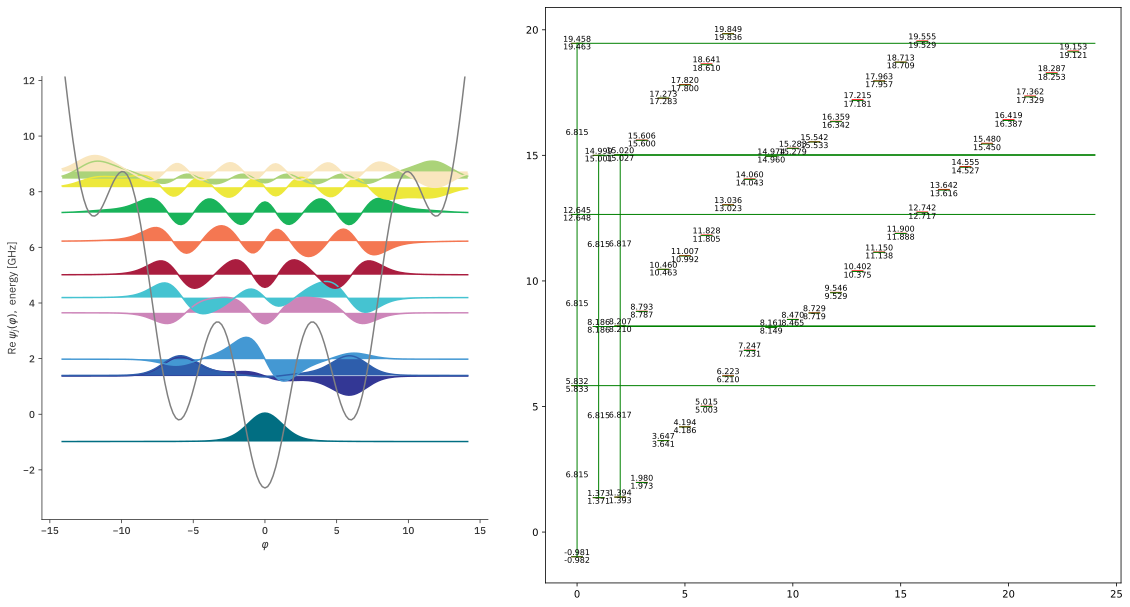

In [6]:

g = 0.23


max_ol = 40
max_ql = 30
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,1'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    ground_freq = dressed_ener(1,0)-dressed_ener(0,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(1,i)-dressed_ener(0,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 2nd state compared to 20-21 (non-linearity): {(dressed_ener(2,i+1)-dressed_ener(2,i))  -(dressed_ener(2,1)-dressed_ener(2,0))}")

    print(f"")
    print(f"00-01: {(dressed_ener(0,1)-dressed_ener(0,0)):.4f}, diff to 20-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 20-01: {abs((dressed_ener(1,1)-dressed_ener(1,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

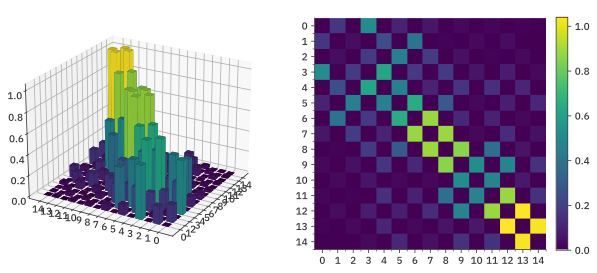

In [54]:
system.qbt.plot_matrixelements(operator = 'n_operator',evals_count = 15)